# Diagnostics! 

#### Importing functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import sys, os
sys.path.append(os.path.abspath("../../"))    # Calling the HorizonFinder.py source code from src
from src.source_v3_2 import nosym

#### Data produced & Plots

In [2]:
# Load data from HDF5 file
with h5py.File("./data/horizon_common.h5", 'r') as f:
    theta = f['theta'][:]
    phi = f['phi'][:]
    h = f['h'][:]

M = 1.0

Ntheta = len(theta)
Nphi = len(phi)

#### 3D Surface Visualization

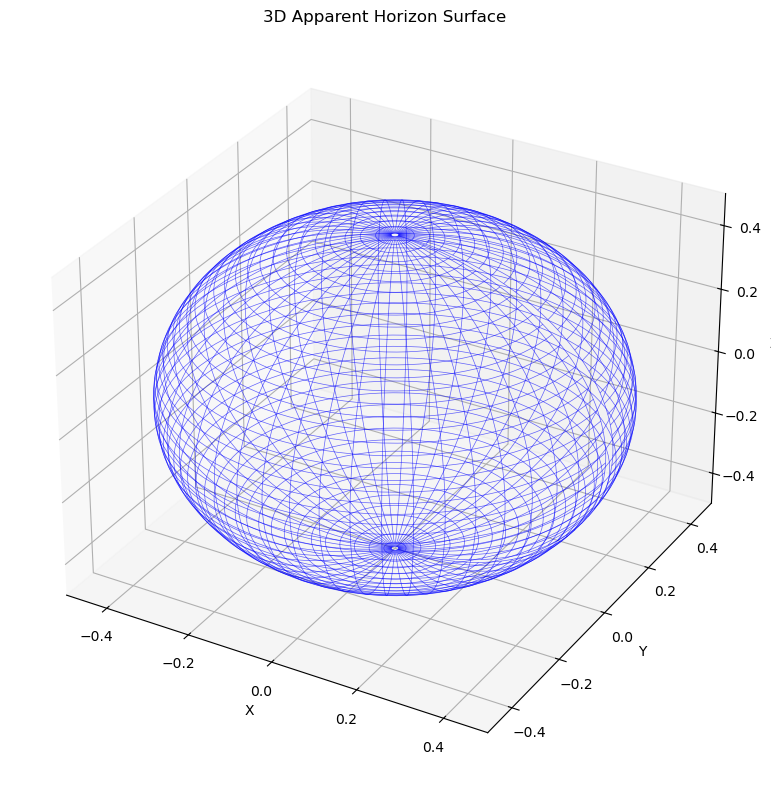

In [3]:
# Convert spherical (r, theta, phi) to Cartesian (x, y, z)
THETA, PHI = np.meshgrid(theta, phi, indexing='ij')
R = h  # horizon surface

X = R * np.sin(THETA) * np.cos(PHI)
Y = R * np.sin(THETA) * np.sin(PHI)
Z = R * np.cos(THETA)

# Create 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the horizon surface as wireframe (mesh only, no color fill)
ax.plot_wireframe(X, Y, Z, color='blue', linewidth=0.5, alpha=0.6)

# Labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Apparent Horizon Surface')

# Equal aspect ratio
max_range = R.max()
ax.set_xlim([-max_range, max_range])
ax.set_ylim([-max_range, max_range])
ax.set_zlim([-max_range, max_range])

plt.tight_layout()
plt.show()

#### Cross-Section Plot

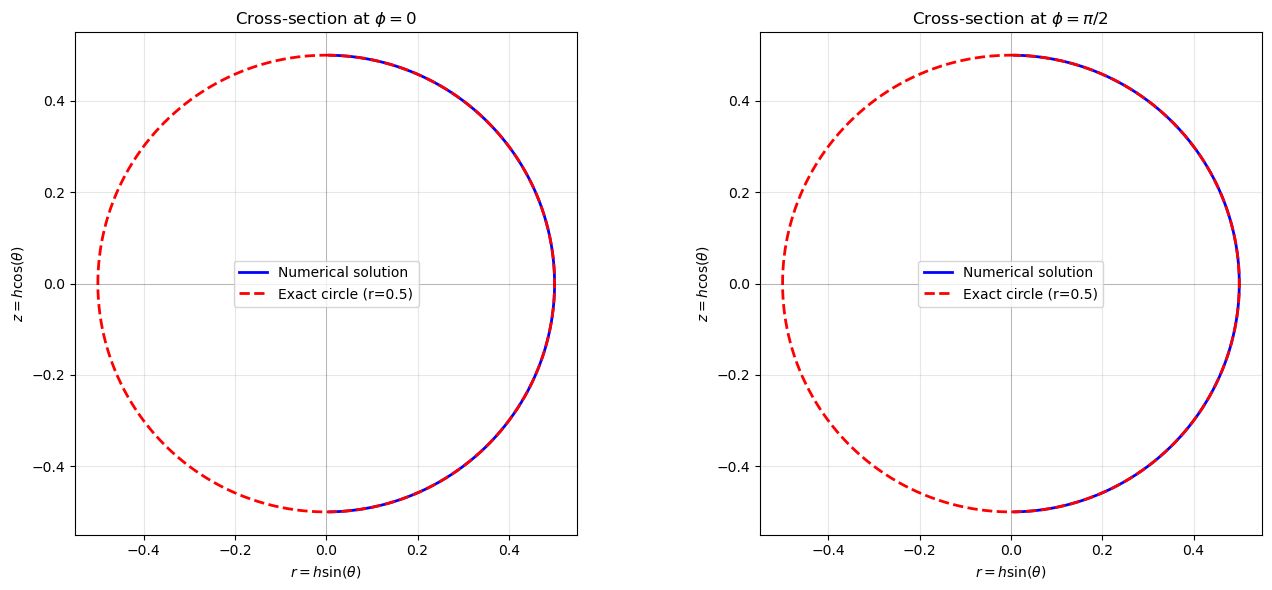

In [4]:
# Cross-section through the equator (phi = 0) and pole (phi = pi/2)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Extract cross-section at phi=0
phi_idx_0 = 0
h_section_0 = h[:, phi_idx_0]
r_equator = h_section_0 * np.sin(theta)
z_equator = h_section_0 * np.cos(theta)

# Extract cross-section at phi=pi/2
phi_idx_90 = len(phi) // 4  # pi/2 location
h_section_90 = h[:, phi_idx_90]
r_meridian = h_section_90 * np.sin(theta)
z_meridian = h_section_90 * np.cos(theta)

# Exact circle
theta_exact = np.linspace(0, 2*np.pi, 200)
r_exact = 0.5 * np.sin(theta_exact)
z_exact = 0.5 * np.cos(theta_exact)

# Plot equatorial cross-section
axes[0].plot(r_equator, z_equator, 'b-', linewidth=2, label='Numerical solution')
axes[0].plot(r_exact, z_exact, 'r--', linewidth=2, label='Exact circle (r=0.5)')
axes[0].axhline(0, color='k', lw=0.5, alpha=0.3)
axes[0].axvline(0, color='k', lw=0.5, alpha=0.3)
axes[0].set_xlabel('$r = h \\sin(\\theta)$')
axes[0].set_ylabel('$z = h \\cos(\\theta)$')
axes[0].set_title(f'Cross-section at $\\phi = 0$')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot meridional cross-section
axes[1].plot(r_meridian, z_meridian, 'b-', linewidth=2, label='Numerical solution')
axes[1].plot(r_exact, z_exact, 'r--', linewidth=2, label='Exact circle (r=0.5)')
axes[1].axhline(0, color='k', lw=0.5, alpha=0.3)
axes[1].axvline(0, color='k', lw=0.5, alpha=0.3)
axes[1].set_xlabel('$r = h \\sin(\\theta)$')
axes[1].set_ylabel('$z = h \\cos(\\theta)$')
axes[1].set_title(f'Cross-section at $\\phi = \\pi/2$')
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()